In [2]:
from lempel_ziv_complexity import lempel_ziv_complexity
from spin_lattices import KagomeLattice, SquareLattice, TriangleLattice, SpinLattice
from heisenberg_hamiltonians import HeisenbergJ1J2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib

2023-04-20 20:19:44.117 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-04-20 20:19:44.120 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-04-20 20:19:44.171 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [29]:
%matplotlib inline

In [2]:
def lz(signal):
    return lempel_ziv_complexity("".join(str(s) for s in signal.astype(int)))

In [3]:
rows = []
lattice: SpinLattice
for lattice in [KagomeLattice(2, 4), SquareLattice(4, 6), TriangleLattice(4, 6)]:
    for J2 in np.linspace(0, 1, 11):
        system = HeisenbergJ1J2(lattice, 1, J2, ground_state_cache_dir=Path("groundstates"))
        system.get_eigenstates(1)
        ground_state = system.get_ground_state_in_full_basis()
        amplitude = np.abs(ground_state)
        amplitude_bin = np.where(amplitude == 0, 0, (amplitude > np.median(amplitude[amplitude != 0])).astype(int) + 1)
        rows.append(dict(J2=J2, lz_complexity=lz(amplitude_bin), lattice=lattice.get_cache_id(), signal="amplitude_median_bin"))
        rows.append(dict(J2=J2, lz_complexity=lz(np.where(ground_state > 0, 1, np.where(ground_state < 0, 2, 0))), lattice=lattice.get_cache_id(), signal="sign"))

2023-04-20 17:16:49.357 | DEBUG    | heisenberg_hamiltonians:__init__:427 - use_symmetries is None and lattice is in symmetries whitelist, setting use_symmetries=True, spin_inversion=1
2023-04-20 17:16:49.358 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=24
2023-04-20 17:16:49.366 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 16 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-20 17:16:49.496 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 85662
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-20 17:16:49.601 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
2023-04-20 17:16:49.678 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -46.1341392314
2023-04-20 17:16:49.679 | DEBUG    | heisenberg

In [4]:
df = pd.DataFrame(rows)

/tmp/ipykernel_11284/154828179.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


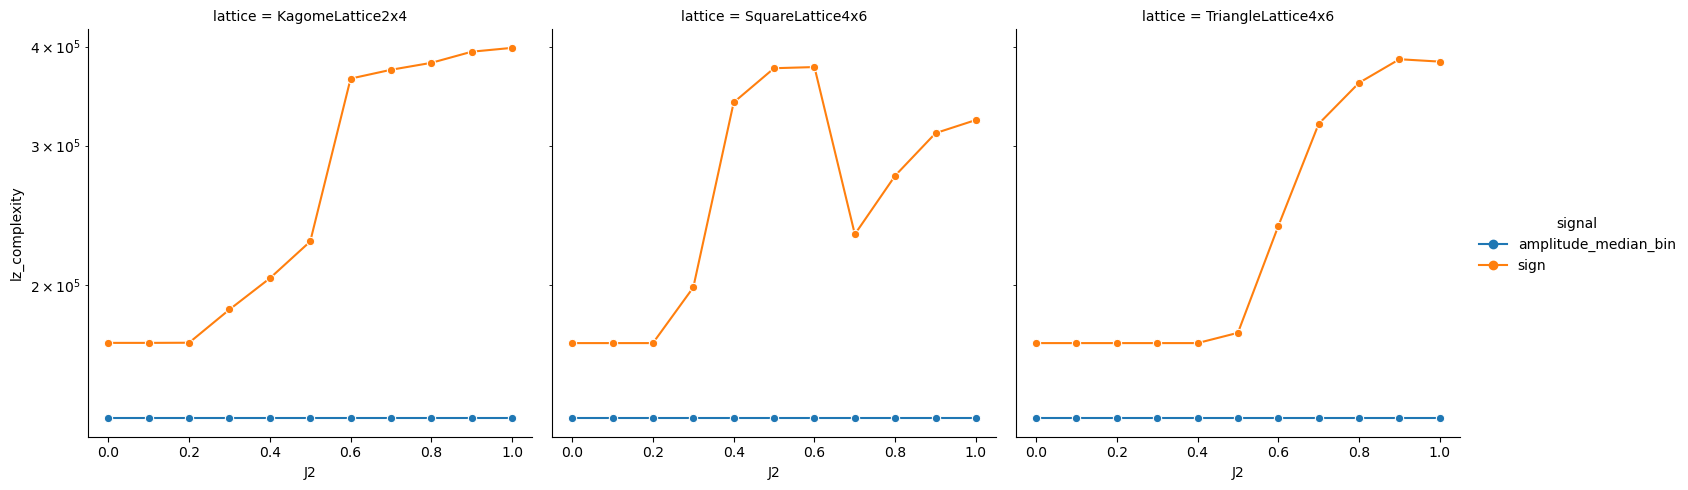

In [5]:
sns.relplot(
    data=df,
    x="J2",
    y="lz_complexity",
    hue="signal",
    col="lattice",
    kind="line",
    markers=["o"],
    style="signal",
    dashes=False,
).set(yscale="log")


<AxesSubplot: xlabel='lattice', ylabel='lz_complexity'>

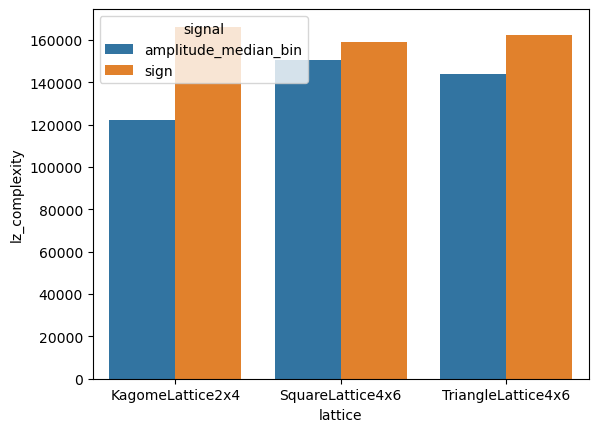

In [42]:
sns.barplot(df.groupby(['lattice', 'signal'])[["lz_complexity"]].max().reset_index(), x="lattice", y="lz_complexity", hue="signal")

In [43]:
rows = []
lattice: SpinLattice
for lattice in [KagomeLattice(2, 2), KagomeLattice(2, 3), KagomeLattice(2, 4)]:
    for J2 in np.linspace(0, 1, 11):
        system = HeisenbergJ1J2(lattice, 1, J2, ground_state_cache_dir=Path("groundstates"))
        system.get_eigenstates(1)
        ground_state = system.get_ground_state_in_canonical_basis()
        amplitude = np.abs(ground_state)
        amplitude_bin = (amplitude > np.median(amplitude)).astype(int)
        rows.append(dict(J2=J2, lz_complexity=lz(amplitude_bin), lattice=lattice.get_cache_id(), signal="amplitude_median_bin"))
        rows.append(dict(J2=J2, lz_complexity=lz(ground_state > 0), lattice=lattice.get_cache_id(), signal="sign"))

2023-04-17 17:16:43.909 | DEBUG    | heisenberg_hamiltonians:__init__:433 - use_symmetries is None and lattice is not in symmetries whitelist, setting use_symmetries=False
2023-04-17 17:16:43.910 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=12
2023-04-17 17:16:43.911 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-17 17:16:43.920 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 924
2023-04-17 17:16:43.932 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-False-None-1.pickle
2023-04-17 17:16:43.952 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -23.2969224448
2023-04-17 17:16:43.958 | DEBUG    | heisenberg_hamiltonians:__init__:433 - use_symmetries is None and lattice is not i

In [8]:
np.unique(amplitude_bin)

array([0, 2])

In [10]:
df_kagome = pd.DataFrame(rows).join(pd.Series({lattice.get_cache_id(): lattice.number_spins for lattice in [KagomeLattice(2, 2), KagomeLattice(2, 3), KagomeLattice(2, 4)]}, name="number_spins"), on="lattice")

/tmp/ipykernel_11284/454254991.py:1: UserWarning: 
The markers list has fewer values (1) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


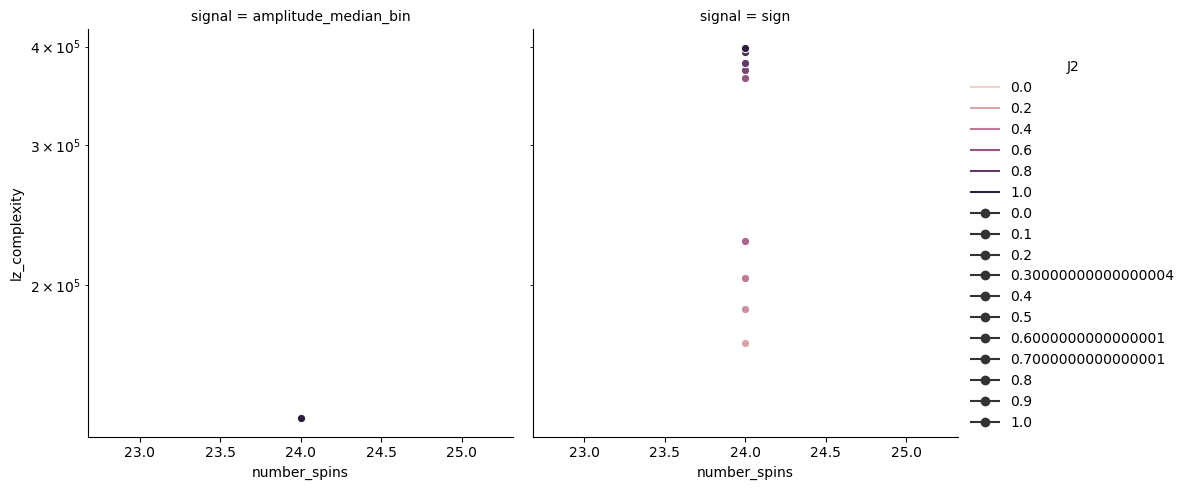

In [11]:
sns.relplot(
    df_kagome,
    x="number_spins",
    y="lz_complexity",
    col="signal",
    hue="J2",
    kind="line",
    markers=["o"],
    style="J2",
    dashes=False,
).set(yscale="log")


In [12]:
sign

NameError: name 'sign' is not defined

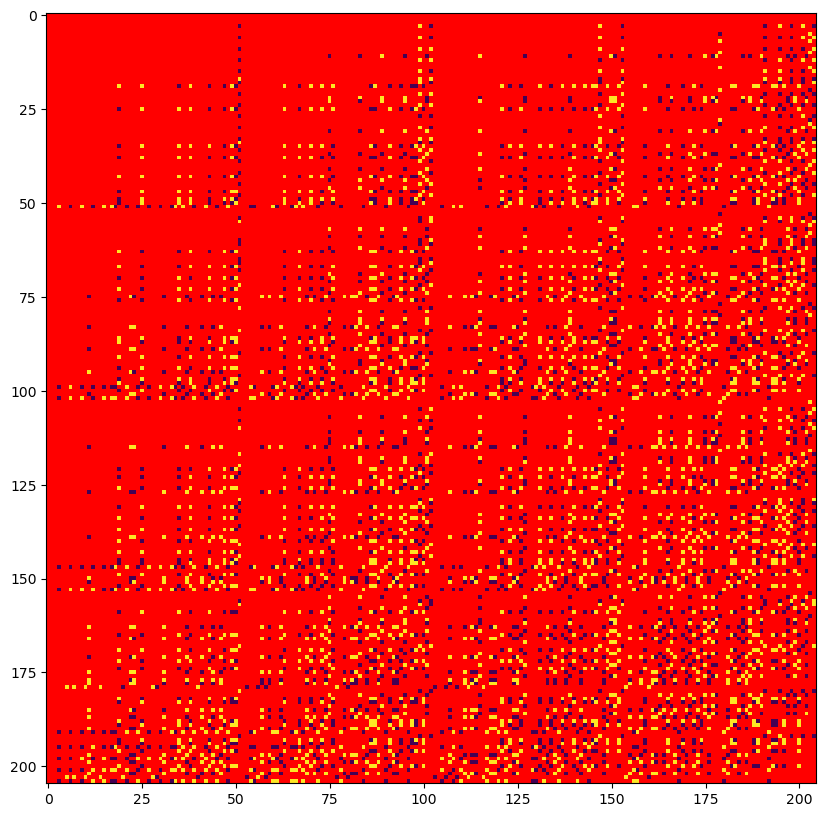

In [37]:
sign = np.where(ground_state > 0, 1, np.where(ground_state < 0, 2, np.nan))
plt.figure(figsize=(10, 10))
sign = sign.reshape(int(np.sqrt(sign.size)), -1).astype(np.float64)
# sign[sign == 0] = np.nan
current_cmap = matplotlib.cm.get_cmap()
current_cmap.set_bad(color='red')
plt.imshow(sign[::20, ::20], cmap=current_cmap)

In [34]:
sign

array([[nan, nan, nan, ..., nan, nan,  1.],
       [nan, nan, nan, ...,  2.,  1., nan],
       [nan, nan, nan, ...,  2.,  1., nan],
       ...,
       [nan,  1.,  2., ..., nan, nan, nan],
       [nan,  1.,  2., ..., nan, nan, nan],
       [ 1., nan, nan, ..., nan, nan, nan]])

In [88]:
from IPython.display import clear_output, display
from time import sleep
from loguru import logger
logger.remove()

In [23]:
images = []
J2s = np.linspace(0, 1, 11)
for J2 in J2s:
    system = HeisenbergJ1J2(KagomeLattice(2, 4), J1=1, J2=J2, ground_state_cache_dir=Path("groundstates"))
    system.get_eigenstates(1)
    sign = np.sign(np.real_if_close(system.get_ground_state_in_full_basis()))
    side = int(np.sqrt(sign.shape[0]))
    image = (sign[:side ** 2].reshape(side, side))
    images.append(image)


2023-04-20 20:29:03.607 | DEBUG    | heisenberg_hamiltonians:__init__:427 - use_symmetries is None and lattice is in symmetries whitelist, setting use_symmetries=True, spin_inversion=1
2023-04-20 20:29:03.610 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=24
2023-04-20 20:29:03.617 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 16 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-20 20:29:03.697 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 85662
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-20 20:29:03.793 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
2023-04-20 20:29:03.795 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -46.1341392314
2023-04-20 20:29:03.796 | DEBUG    | heisenberg

KeyboardInterrupt: 

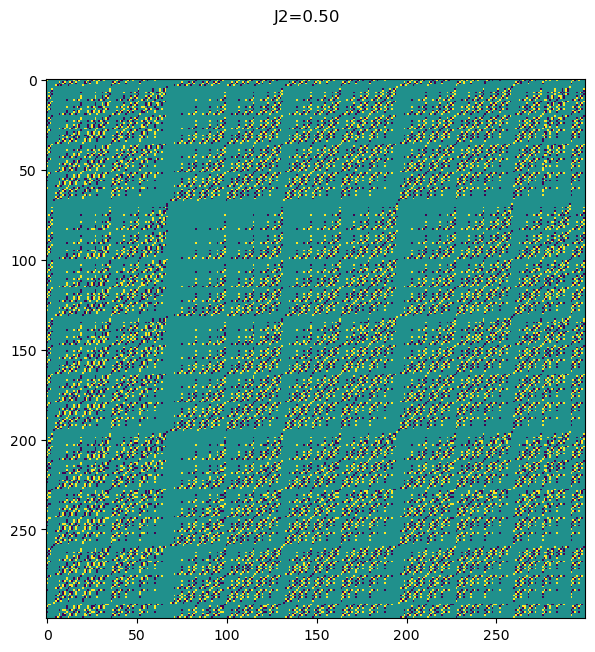

In [101]:
while True:
    for J2, image in zip(J2s, images):
        fig = plt.figure(figsize=(7, 7))
        clear_output(wait=True)
        plt.imshow(image, interpolation="none")
        plt.suptitle(f"J2={J2:.2f}")
        display(fig)
        sleep(0.5)
        plt.close(fig)

In [33]:
from scipy.ndimage import gaussian_filter

In [39]:
def structural_multiscale_complexity(image, max_scale=None):
    upper_scale = int(np.log2(max(image.shape)))
    if max_scale is not None:
        upper_scale = min(upper_scale, max_scale)
    return sum(
        np.abs(gaussian_filter(image, 2 ** scale - 1) - gaussian_filter(image, 2 ** (scale + 1) - 1)).mean()
        for scale in range(max_scale)
        )

In [43]:
int(np.log2(max(images[-1].shape)))

12

In [42]:
structural_multiscale_complexity(images[-1], max_scale=5)

0.2617834042080844

In [44]:
complexities = [structural_multiscale_complexity(image, max_scale=5) for image in images]

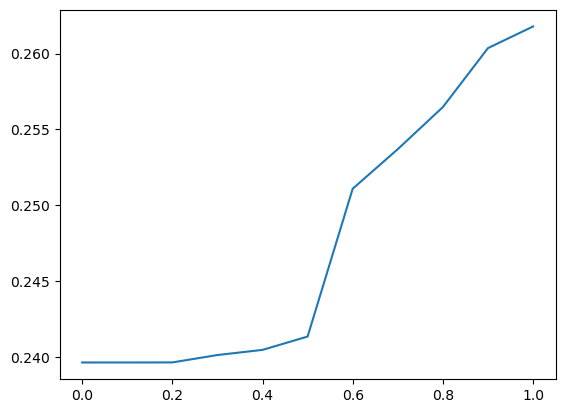

In [45]:
plt.plot(J2s, complexities)

In [117]:
gaussian_filter(image.reshape(-1, 1), 1)

array([[0.64091492],
       [0.29596257],
       [0.05842299],
       ...,
       [0.        ],
       [0.        ],
       [0.        ]])

In [121]:
structural_multiscale_complexity(image[-1].reshape(-1, 1))

0

In [6]:
vector = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
np.repeat(vector.reshape(-1, 2).mean(axis=1), 2) - vector

array([ 0.5, -0.5,  0.5, -0.5,  0.5, -0.5,  0.5, -0.5,  0.5, -0.5])

In [46]:
def smc_1d(image):
    return sum(
        np.abs(
            image.reshape(-1, 2**scale).mean(axis=1)
            - np.repeat(image.reshape(-1, 2 ** (scale + 1)).mean(axis=1), 2)
        ).mean()
        for scale in range(int(np.log2(max(image.shape))))
    )

In [47]:
complexities = [smc_1d(image.reshape(-1)) for image in images]

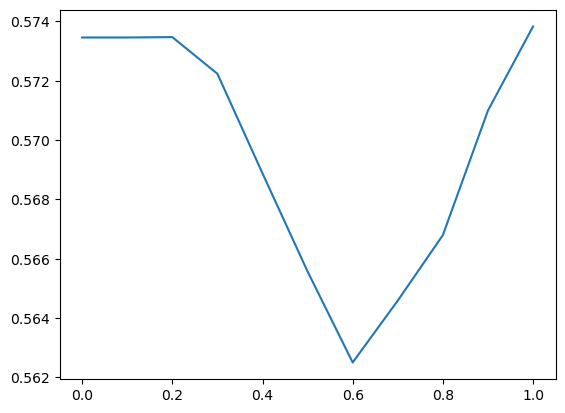

In [48]:
plt.plot(J2s, complexities)

In [25]:
image.shape

(4096, 4096)

In [26]:
smc_1d(image.reshape(-1))